In [1]:
!nvidia-smi

Sun Apr  5 15:10:12 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   37C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
%pip install datasets tqdm pandas matplotlib langchain sentence_transformers faiss-gpu-cu12 langchain-community torch accelerate fastapi pyngrok uvicorn nest_asyncio


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.6/193.6 kB 7.4 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2026.3.0
    Uninstalling fsspec-2026.3.0:
      Successfully uninstalled fsspec-2026.3.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.31.0 requires rich<14,>=12.4.4, but you have rich 14.3.3 which is incompatible.


In [2]:
import faiss
print(f"FAISS GPU confirmed: {faiss.get_num_gpus()} GPU(s) found.")


FAISS GPU confirmed: 1 GPU(s) found.


In [3]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
from google.colab import drive
import pandas as pd
from tqdm.notebook import tqdm
from langchain_core.documents import Document as LangchainDocument

# Step 1: Mount your Google Drive
# You will see a popup asking for permission to connect.
drive.mount('/content/drive')

# Step 2: Set the path (Drive files are always nested under "MyDrive")
file_path = "/content/drive/MyDrive/Registration_info_dataset123.txt"

pd.set_option("display.max_colwidth", None)

try:
    with open(file_path, "r") as fp:
        s = fp.read().split("\n\n\n\n")
    
    RAW_KNOWLEDGE_BASE = [
        LangchainDocument(page_content=doc)
        for doc in tqdm(s)
    ]
    print(f"Successfully loaded {len(RAW_KNOWLEDGE_BASE)} documents from Google Drive.")
except FileNotFoundError:
    print(f"ERROR: '{file_path}' not found. Please double-check the file name in your Google Drive.")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


  0%|          | 0/1633 [00:00<?, ?it/s]

Successfully loaded 1633 documents from Google Drive.


  0%|          | 0/4260 [00:00<?, ?it/s]

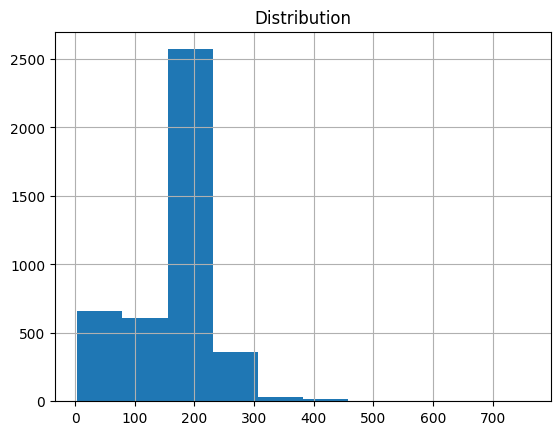

In [6]:
# Re-importing after the runtime restart
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
from langchain_text_splitters import RecursiveCharacterTextSplitter
from sentence_transformers import SentenceTransformer
from transformers import AutoTokenizer

MARKDOWN_SEPARATORS = [
    "\n#{1,6}",
    "```\n",
    "\n\\*\\*\\*+\n",
    "\n---+\n",
    "\n__+\n",
    "\n\n",
    "\n",
    " ",
    ""
]

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000,
    chunk_overlap=100,
    add_start_index=True,
    strip_whitespace=True,
    separators=MARKDOWN_SEPARATORS,
)

docs_processed = []
for doc in RAW_KNOWLEDGE_BASE:
    docs_processed += text_splitter.split_documents([doc])

tokenizer = AutoTokenizer.from_pretrained("thenlper/gte-small")
lengths = [len(tokenizer.encode(doc.page_content)) for doc in tqdm(docs_processed)]

fig = pd.Series(lengths).hist()
fig.set_title("Histogram of Document Lengths")
plt.title("Distribution")
plt.show()


In [7]:
from typing import Optional, List
from langchain_text_splitters import RecursiveCharacterTextSplitter
from transformers import AutoTokenizer
EMBEDDING_MODEL_NAME = "thenlper/gte-small"
def split_documents(
        chunk_size: int,
        knowledge_base: list[LangchainDocument],
        tokenizer_name: Optional[str] = EMBEDDING_MODEL_NAME,
) -> list[LangchainDocument]:
    text_splitter = RecursiveCharacterTextSplitter.from_huggingface_tokenizer(
        AutoTokenizer.from_pretrained(tokenizer_name),
        chunk_size=chunk_size,
        chunk_overlap=int(chunk_size / 10),
        add_start_index=True,
        strip_whitespace=True,
        separators=MARKDOWN_SEPARATORS,
    )
    docs_processed = []
    for doc in knowledge_base:
        docs_processed += text_splitter.split_documents([doc])

    unique_texts = {}
    docs_processed_unique = []
    for doc in docs_processed:
        if doc.page_content not in unique_texts:
            unique_texts[doc.page_content] = True
            docs_processed_unique.append(doc)
    return docs_processed_unique

docs_processed = split_documents(512, RAW_KNOWLEDGE_BASE, tokenizer_name=EMBEDDING_MODEL_NAME)
print(len(docs_processed))
print(docs_processed[0:3])

2227
[Document(metadata={'start_index': 0}, page_content='Question: Q1. HOW IS OWNERSHIP OF IMMOVABLE PROPERTY ACQUIRED?\nAnswer: Ans:-A person may acquire immovable property in any of the following ways:Download SVGPerfect for when you want to use just one icon as a vector on the desktop or in your own icon workflow.By inheritance of ancestral property.Through will.By way of purchase etc.Through gift, trust, settlement deeds.Through Grant, sanad / Inam by the Government.Through partition deed.Through decree of Court.There are two ways of acquisition:By act of parties.Example:Purchase, gift etc.By operation of law.Example:Inheritance, decree of Court etc. (for details please see Transfer of Property Act, 1882 (Central Act))'), Document(metadata={'start_index': 0}, page_content='Question: Q2. IS IT NECESSARY TO GET DOCUMENT REGISTERED IN THE OFFICE OF SUB- REGISTRAR FOR PATTA/KHATA TRANSFER (MUTATION) IN       RESPECT OF PROPERTY ACQUIRED BY INHERITANCE?\nAnswer: Ans:-Not necessary. Aft

In [8]:
# Updated import for modern LangChain
from langchain_community.vectorstores import FAISS
from langchain_community.embeddings import HuggingFaceEmbeddings
from langchain_community.vectorstores.utils import DistanceStrategy
import torch

embedding_model = HuggingFaceEmbeddings(
    model_name=EMBEDDING_MODEL_NAME,
    multi_process=True,
    model_kwargs={"device": "cuda"},
    encode_kwargs={"normalize_embeddings": True},
)

KNOWLEDGE_VECTOR_DATABASE = FAISS.from_documents(
    docs_processed,
    embedding_model,
    distance_strategy=DistanceStrategy.COSINE,
)


/tmp/ipython-input-3216268696.py:7: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the `langchain-huggingface package and should be used instead. To use it run `pip install -U `langchain-huggingface` and import as `from `langchain_huggingface import HuggingFaceEmbeddings``.
  embedding_model = HuggingFaceEmbeddings(


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: thenlper/gte-small
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
%pip install bitsandbytes


In [ ]:
%pip install -U transformers accelerate bitsandbytes


In [ ]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer, pipeline, BitsAndBytesConfig

# 1. Configuration
model_id = "meta-llama/Llama-3.1-8B-Instruct"
hf_token = "YOUR_HUGGINGFACE_TOKEN"

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16
)

# 2. Load Model and Tokenizer
print("Loading model (this will use about 5.5GB of VRAM)...")
model = AutoModelForCausalLM.from_pretrained(
    model_id,
    token=hf_token,
    device_map="auto",
    quantization_config=bnb_config,
    trust_remote_code=True
)

tokenizer = AutoTokenizer.from_pretrained(model_id, token=hf_token)
tokenizer.pad_token = tokenizer.eos_token

# 3. Create Pipeline
pipe = pipeline(
    "text-generation",
    model=model,
    tokenizer=tokenizer,
)

print("Model successfully loaded on T4 GPU!")


Loading model (this will use about 5.5GB of VRAM)...


model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/184 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/296 [00:00<?, ?B/s]

Model successfully loaded on T4 GPU!


In [14]:
!nvidia-smi


Sun Apr  5 16:41:37 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   66C    P0             30W /   70W |   13145MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [15]:
!kill -9 682


In [13]:
prompt_chat = [
     {
        "role": "system",
        "content": """You are an expert Registration Information Assistant. 
Your goal is to provide accurate information based on the provided Context, which may contain various laws, government orders, or registration procedures.
Guidelines:
1. **Source Extraction**: Identify the specific Act, Department, or Document mentioned in the Context and include it in your Reference section.
2. **Structure**: 
   - **Answer**: Provide a direct and helpful summary.
   - **Reference**: Cite the specific source or Authority found in the context.
3. **Accuracy**: If the answer is not in the context, simply state that you don't have information on that specific registration topic at this time.
4. **General Disclaimer**: Always note that the information is for guidance and users should verify with the relevant official department."""
    },
    {
        "role": "user",
        "content": """Context:
{context}
---
Now here is the Question you need to answer.
Question:{question}""",
    },
]

RAG_PROMPT_TEMPLATE = tokenizer.apply_chat_template(
    prompt_chat, tokenize=False, add_generation_prompt=True,
)
print(RAG_PROMPT_TEMPLATE)

<|begin_of_text|><|start_header_id|>system<|end_header_id|>

Cutting Knowledge Date: December 2023
Today Date: 26 Jul 2024

You are an expert Registration Information Assistant. 
Your goal is to provide accurate information based on the provided Context, which may contain various laws, government orders, or registration procedures.
Guidelines:
1. **Source Extraction**: Identify the specific Act, Department, or Document mentioned in the Context and include it in your Reference section.
2. **Structure**: 
   - **Answer**: Provide a direct and helpful summary.
   - **Reference**: Cite the specific source or Authority found in the context.
3. **Accuracy**: If the answer is not in the context, simply state that you don't have information on that specific registration topic at this time.
4. **General Disclaimer**: Always note that the information is for guidance and users should verify with the relevant official department.<|eot_id|><|start_header_id|>user<|end_header_id|>

Context:
{context

In [ ]:
# # give the match summary between punjab kings  and  chennai super kings on
# u_query = "What are the major conditions for hindu marriage?"
# # ret_text = KNOWLEDGE_VECTOR_DATABASE.similarity_search(query=u_query,k=3)
# retrieved_docs = KNOWLEDGE_VECTOR_DATABASE.similarity_search(query=u_query,k=3)

# context = retrieved_docs[0].page_content
# final_prompt = RAG_PROMPT_TEMPLATE.format(
#     question= u_query, context = context
# )

# output = pipe(final_prompt, **generation_args)
# print("YOUR QUESTION:\n",u_query,"\n")
# print("MICROSOFT 128K ANSWER: \n",output[0]['generated_text'])

In [16]:
u_query = "what are the major conditions for hindu marraige?"

retrieved_docs_with_scores = KNOWLEDGE_VECTOR_DATABASE.similarity_search_with_score(query=u_query, k=3)
print("======================================\n")
for i in retrieved_docs_with_scores:
    print(i)
    print()
print("======================================\n")

retrieved_docs = [doc for doc, score in retrieved_docs_with_scores]
similarity_scores = [score for doc, score in retrieved_docs_with_scores]

print("\nSimilarity scores of the retrieved documents:", similarity_scores)
threshold_lower = 0.155
threshold_upper = 0.349

score_within_range = any(threshold_lower <= score <= threshold_upper for score in similarity_scores)

if score_within_range:
    context = retrieved_docs[0].page_content
    final_prompt = RAG_PROMPT_TEMPLATE.format(
        question=u_query, context=context
    )
    output = pipe(final_prompt, max_new_tokens=500, return_full_text=False, temperature=0.0, do_sample=False)
    print("\nAnswer found within the specified score range:")
    print("YOUR QUESTION:\n", u_query, "\n")
    print("MICROSOFT 128K ANSWER:\n", output[0]['generated_text'])
else:
    print("\nYour question is not found in the dataset.")

The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
Passing `generation_config` together with generation-related arguments=({'max_new_tokens', 'do_sample', 'temperature'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Both `max_new_tokens` (=500) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



(Document(id='dd45cc37-d861-43f7-81de-a163029f4590', metadata={'start_index': 0}, page_content='Question: Content from https://registration.telangana.gov.in/resources/downloads/HinduMarriageAct.pdf - Page 4\nAnswer: CHAPTER II  \nHINDU MARRIAGES  \n5. Conditions for a Hindu marriage  \nA marriage may be solemnised between any two Hindus, if the following conditions are \nfulfilled, namely, - \n(i) neither party has a spouse living at the time of the marriage;  \n(ii)  at the time of the marriage, neither party - \n(a) is incapable of giving a valid consent to it in consequence of unsoundness of mind;  \nor \n(b) though capable of giving a valid consent, has been suffering from mental disorder of \nsuch a kind or to such an extent as to  be unfit for marriage and the procreation of children; \nor \n(c) has been subject to recurrent attacks of insanity or epilepsy;  \n(iii) the bridegroom has completed the age of twenty one years and the bride, the age  \nof eighteen years at the time o

In [ ]:
%pip install pyngrok
from pyngrok import ngrok

# Use your new authtoken here
auth_token = "2wE9yU0hK3W0H4iBM3B2OxNWPkA_7yxsy911qCZvTeBF2T4Nk"
ngrok.set_auth_token(auth_token)

print("Ngrok Authtoken successfully updated!")


Ngrok Authtoken successfully updated!                                                               


In [ ]:
%pip install uvicorn
from fastapi import FastAPI
from fastapi.middleware.cors import CORSMiddleware
from pydantic import BaseModel
from pyngrok import ngrok
import uvicorn
import nest_asyncio

# Initialize FastAPI app
app = FastAPI()

# Set up CORS middleware to allow all origins for development purposes
app.add_middleware(
    CORSMiddleware,
    allow_origins=["*"],  # Allows all origins
    allow_credentials=True,
    allow_methods=["*"],  # Allows all methods
    allow_headers=["*"],  # Allows all headers
)

class QueryModel(BaseModel):
    query: str

# Define constants for the similarity score thresholds
THRESHOLD_LOWER = 0.112
THRESHOLD_UPPER = 0.349

@app.post("/query")
async def query_api(request: QueryModel):
    u_query = request.query

    # Retrieve documents with their similarity scores
    retrieved_docs_with_scores = KNOWLEDGE_VECTOR_DATABASE.similarity_search_with_score(query=u_query, k=3)

    # Extract documents and their scores
    retrieved_docs = [doc for doc, score in retrieved_docs_with_scores]
    similarity_scores = [score for doc, score in retrieved_docs_with_scores]

    # Check if any score is within the specified range
    score_within_range = any(THRESHOLD_LOWER <= score <= THRESHOLD_UPPER for score in similarity_scores)

    if score_within_range:
        context = retrieved_docs[0].page_content
        final_prompt = RAG_PROMPT_TEMPLATE.format(
            question=u_query, context=context
        )
        output = pipe(final_prompt, max_new_tokens=500, return_full_text=False, temperature=0.0, do_sample=False)
        return {"question": u_query, "answer": output[0]['generated_text']}
    else:
        return {"question": u_query, "answer": "Your question is not found in the dataset."}

In [ ]:
import asyncio
import nest_asyncio
from pyngrok import ngrok
import uvicorn

# 1. Patch the loop
nest_asyncio.apply()

# 2. Kill old ngrok processes
!pkill -f ngrok

# 3. Setup Ngrok
auth_token = "2wE9yU0hK3W0H4iBM3B2OxNWPkA_7yxsy911qCZvTeBF2T4Nk"
ngrok.set_auth_token(auth_token)
public_url = ngrok.connect(8000)
print(f"Your chatbot is LIVE at: {public_url.public_url}")

# 4. Define a manual serve function
async def start_server():
    config = uvicorn.Config(app, host="0.0.0.0", port=8000, loop="asyncio")
    server = uvicorn.Server(config)
    await server.serve()

# 5. Run it within the existing notebook loop
if __name__ == "__main__":
    loop = asyncio.get_event_loop()
    loop.create_task(start_server())


Your chatbot is LIVE at: https://9260-34-187-135-191.ngrok-free.app


INFO:     Started server process [18172]
INFO:     Waiting for application startup.
INFO:     Application startup complete.
INFO:     Uvicorn running on http://0.0.0.0:8000 (Press CTRL+C to quit)


: 